# Exploratory Data Analysis (EDA)

In this notebook, I'll take a look at the Appliance Energy Prediction Dataset. The main things I want to figure out are:
1. What the data actually looks like
2. Basic summary stats 
3. If there are missing values and how to handle them
4. How the target variables are distributed
5. Look at correlations and some time-series trends

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Load the dataset
data_path = '../data/raw/energy_data_set.csv'
try:
    df = pd.read_csv(data_path)
    # Convert simply 'date' column to datetime
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date', inplace=True)
    
    print(f"Dataset shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print(f"File not found at {data_path}. Please ensure the dataset is downloaded.")

Dataset shape: (19735, 28)


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


### 1. Data Understanding & Summary Stats
First, let's just check the data types and basic statistics to see what kind of scale we're dealing with for these features.

In [4]:
# Check data types and for any missing values directly
print(df.info())

# Basic summary statistics
display(df.describe())

<class 'pandas.DataFrame'>
DatetimeIndex: 19735 entries, 2016-01-11 17:00:00 to 2016-05-27 18:00:00
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   19735 non-null  int64  
 1   lights       19735 non-null  int64  
 2   T1           19735 non-null  float64
 3   RH_1         19735 non-null  float64
 4   T2           19735 non-null  float64
 5   RH_2         19735 non-null  float64
 6   T3           19735 non-null  float64
 7   RH_3         19735 non-null  float64
 8   T4           19735 non-null  float64
 9   RH_4         19735 non-null  float64
 10  T5           19735 non-null  float64
 11  RH_5         19735 non-null  float64
 12  T6           19735 non-null  float64
 13  RH_6         19735 non-null  float64
 14  T7           19735 non-null  float64
 15  RH_7         19735 non-null  float64
 16  T8           19735 non-null  float64
 17  RH_8         19735 non-null  float64
 18  T9           19735 non

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


### 2. Handling Missing Values
Let's see if we have any NaNs. With time-series data, it's usually better to interpolate or fill forward/backward rather than just dropping rows, otherwise we break the time sequence.

In [5]:
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])

# Just in case, let's set up an interpolation method for any missing time-series points
if missing_values.sum() > 0:
    print("Interpolating missing values...")
    df = df.interpolate(method='time')
else:
    print("No missing values found.")

Missing values per column:
 Series([], dtype: int64)
No missing values found.


### 3. Distribution Analysis
Let's plot out our target variable (`Appliances` energy consumption) along with the `lights` column just to see what the shape looks like.

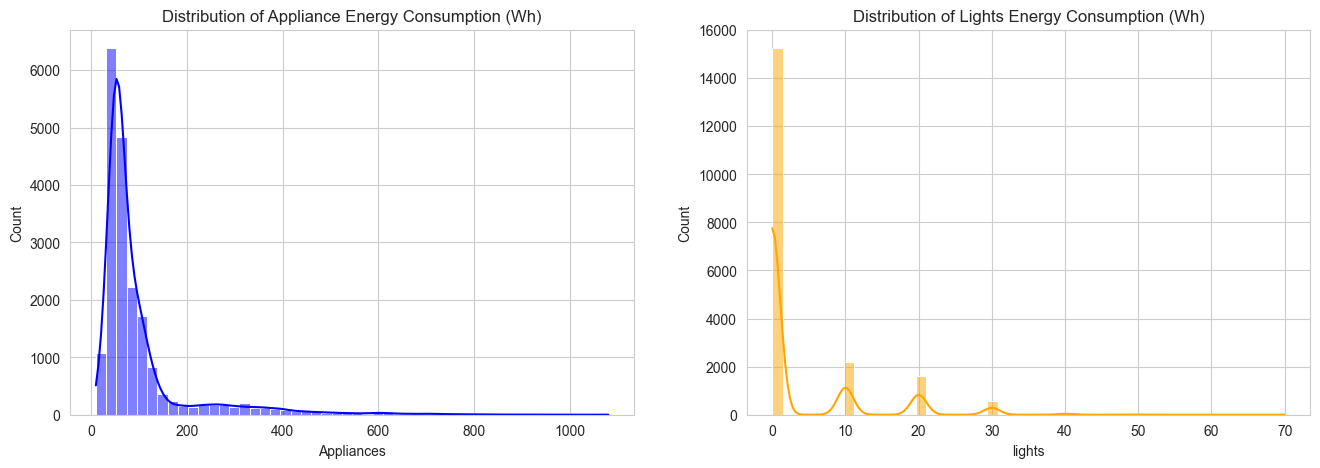

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Target Variable (Appliances)
sns.histplot(df['Appliances'], bins=50, kde=True, ax=ax[0], color='blue')
ax[0].set_title('Distribution of Appliance Energy Consumption (Wh)')

# Lights Variable
if 'lights' in df.columns:
    sns.histplot(df['lights'], bins=50, kde=True, ax=ax[1], color='orange')
    ax[1].set_title('Distribution of Lights Energy Consumption (Wh)')
else:
    print("Column 'lights' not found, skipping its plot.")

plt.show()

### 4. Correlation Matrix
I'll run a quick heatmap to check for multicollinearity among the temperature and humidity sensors, and see what correlates best with the `Appliances` column.

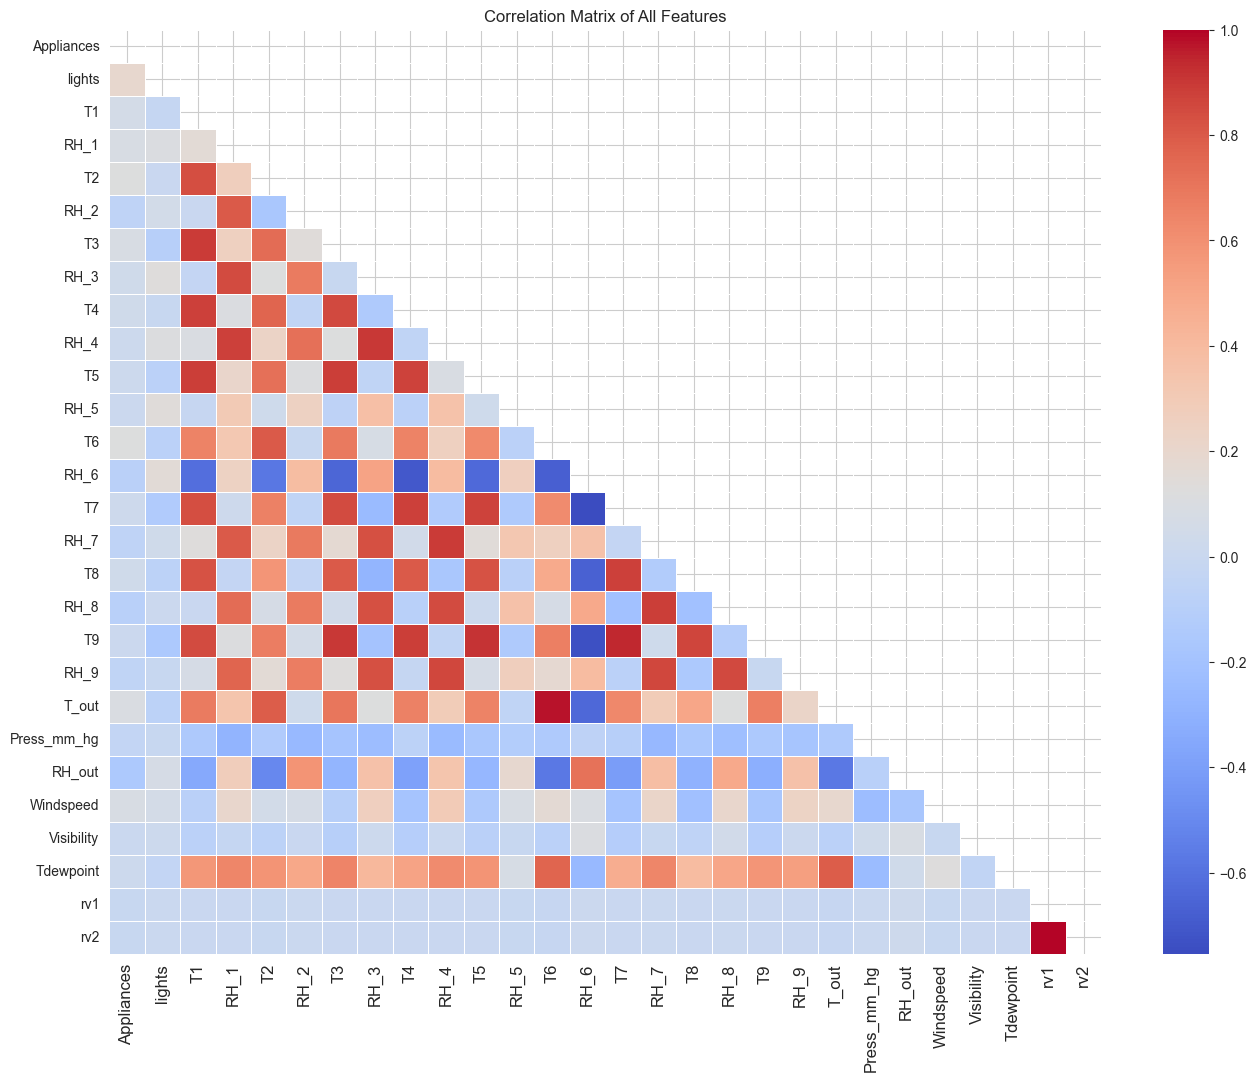

Top correlations with Appliances:
Appliances    1.000000
lights        0.197278
T2            0.120073
T6            0.117638
T_out         0.099155
Windspeed     0.087122
RH_1          0.086031
T3            0.085060
T1            0.055447
T4            0.040281
Name: Appliances, dtype: float64

Bottom correlations with Appliances:
RH_out        -0.152282
RH_8          -0.094039
RH_6          -0.083178
RH_2          -0.060465
RH_7          -0.055642
RH_9          -0.051462
Press_mm_hg   -0.034885
rv1           -0.011145
rv2           -0.011145
Visibility     0.000230
Name: Appliances, dtype: float64


In [ ]:
plt.figure(figsize=(16, 12))
# Only correlate numeric columns
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Mask the upper triangle for easier readability
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of All Features')
plt.xticks(fontsize=12)
plt.show()

# Let's see the top variables correlated with Appliances
print("Top correlations with Appliances:")
print(corr_matrix['Appliances'].sort_values(ascending=False).head(10))
print("\nBottom correlations with Appliances:")
print(corr_matrix['Appliances'].sort_values(ascending=True).head(10))

### 5. Time-Series Trends & Resampling
Since the original data is recorded every 10 minutes, the charts can look super messy and volatile. To get a better sense of the overall patterns, I'll compare a snapshot of the raw 10-minute data against a smoothed-out daily average.

In [ ]:
# Plot the raw 10-minute frequency vs Daily average
fig, ax = plt.subplots(2, 1, figsize=(16, 12))

# Subplot 1: A one-week snapshot of 10-minute raw data to see micro-seasonality
one_week_data = df.loc['2016-01-11':'2016-01-18']
ax[0].plot(one_week_data.index, one_week_data['Appliances'], color='blue', linewidth=1)
ax[0].set_title('10-Minute Energy Consumption (1 Week Snapshot)')
ax[0].set_ylabel('Appliances (Wh)')

# Subplot 2: Entire dataset resampled to Daily Average
daily_data = df['Appliances'].resample('D').mean()
ax[1].plot(daily_data.index, daily_data, color='purple', linewidth=2)
ax[1].set_title('Daily Average Energy Consumption (Entire Period)')
ax[1].set_ylabel('Appliances (Wh)')

plt.tight_layout()
plt.show()

### 6. Temporal Boxplots (Finding behavioral patterns)
Finally, let's look at energy usage grouped by the Hour of the day, and by the Day of the week. This should show us obvious human behavioral patterns (like when people wake up or come home) and help spot outliers.

In [ ]:
# First, add temporary hour and day of week attributes for plotting
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.day_name()
# Order the days correctly
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['DayOfWeek'] = pd.Categorical(df['DayOfWeek'], categories=days_order, ordered=True)

fig, ax = plt.subplots(2, 1, figsize=(16, 14))

# Hourly Boxplot
sns.boxplot(x='Hour', y='Appliances', data=df, ax=ax[0], palette='viridis')
ax[0].set_title('Energy Consumption Distribution per Hour of the Day')

# Day of Week Boxplot
sns.boxplot(x='DayOfWeek', y='Appliances', data=df, ax=ax[1], palette='viridis')
ax[1].set_title('Energy Consumption Distribution per Day of the Week')

plt.tight_layout()
plt.show()

# Cleanup temporary columns
df.drop(columns=['Hour', 'DayOfWeek'], inplace=True)